# Automated Chest X-Ray Analysis - Model Training (Colab)

This notebook trains a DenseNet121 model to detect Pneumonia (Viral/Bacterial) from Chest X-Rays.  
It implements **Weighted Loss** to handle class imbalance.

In [1]:
!pip install -q torchxrayvision albumentations grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 86.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 26.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import copy
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Run the setup script we created locally
# Upload 'colab_data_setup.py' and 'kaggle.json' before running this!
if not os.path.exists('colab_data_setup.py'):
    print("WARNING: colab_data_setup.py not found. Please upload it.")
else:
    !python colab_data_setup.py

✅ Found credentials file: kaggle.json
✅ Moved to ~/.kaggle/kaggle.json and set permissions.
⬇️ Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:21<00:00, 251MB/s]
100% 2.29G/2.29G [00:21<00:00, 116MB/s]
✅ Dataset downloaded!
🔄 Re-organizing dataset logic...
   -> Found 11712 images.
✂️ Splitting data (Train: 80%, Val: 10%, Test: 10%)...
✅ Dataset organization complete!
   -> Data ready at /content/processed_data


## Data Loading & Augmentation

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomAffine(degrees=10, translate=(0.02, 0.02)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/processed_data'
if not os.path.exists(data_dir):
    print("Data directory not found. Did the setup script run successfully?")
else:
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                              data_transforms[x])
                      for x in ['train', 'val']}

    dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                                 shuffle=True, num_workers=2)
                  for x in ['train', 'val']}

    class_names = image_datasets['train'].classes
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
    print(f"Classes: {class_names}")
    print(f"Dataset Sizes: {dataset_sizes}")

Classes: ['BACTERIA', 'NORMAL', 'VIRUS']
Dataset Sizes: {'train': 4659, 'val': 603}


## Calculate Class Weights

In [5]:
# Get labels from dataset
if os.path.exists(data_dir):
    targets = image_datasets['train'].targets
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    print(f"Class Weights: {class_weights}")
else:
    print("Skipping weight calculation (no data).")

Class Weights: [0.70335145 1.24339472 1.29201331]


## Model Setup (DenseNet121)

In [6]:
model_ft = models.densenet121(pretrained=True)

# Modify the last layer for our 3 classes (Normal, Bacteria, Virus)
num_ftrs = model_ft.classifier.in_features
# Ensure class_names exists if running without data for testing logic
num_classes = len(class_names) if 'class_names' in locals() else 3
model_ft.classifier = nn.Linear(num_ftrs, num_classes)

model_ft = model_ft.to(device)

# Weighted Cross Entropy Loss
if 'class_weights_tensor' in locals():
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 181MB/s]


In [7]:
# Training Loop
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            # Use tqdm if running locally or in notebook for progress bar
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best one so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Start Training
if 'dataloaders' in locals():
    model_ft = train_model(model_ft, criterion, optimizer_ft, scheduler, num_epochs=10)
else:
    print("Dataloaders not defined. Cannot train.")

Epoch 0/9
----------
train Loss: 0.6360 Acc: 0.7042
val Loss: 0.6394 Acc: 0.7197

Epoch 1/9
----------
train Loss: 0.5313 Acc: 0.7583
val Loss: 0.5610 Acc: 0.7347

Epoch 2/9
----------
train Loss: 0.4982 Acc: 0.7733
val Loss: 0.8256 Acc: 0.6302

Epoch 3/9
----------
train Loss: 0.4755 Acc: 0.7901
val Loss: 0.5499 Acc: 0.7081

Epoch 4/9
----------
train Loss: 0.4607 Acc: 0.7976
val Loss: 0.4290 Acc: 0.7629

Epoch 5/9
----------
train Loss: 0.4610 Acc: 0.7987
val Loss: 0.5669 Acc: 0.8076

Epoch 6/9
----------
train Loss: 0.4433 Acc: 0.8064
val Loss: 0.4141 Acc: 0.7877

Epoch 7/9
----------
train Loss: 0.3537 Acc: 0.8500
val Loss: 0.3372 Acc: 0.8574

Epoch 8/9
----------
train Loss: 0.3174 Acc: 0.8667
val Loss: 0.3424 Acc: 0.8524

Epoch 9/9
----------
train Loss: 0.3002 Acc: 0.8706
val Loss: 0.3448 Acc: 0.8574

Training complete in 15m 24s
Best val Acc: 0.857380


In [8]:
# Save Model
torch.save(model_ft.state_dict(), '/content/densenet121_pneumonia.pth')
print("Model saved to /content/densenet121_pneumonia.pth")

Model saved to /content/densenet121_pneumonia.pth


## Evaluation

              precision    recall  f1-score   support

    BACTERIA       0.92      0.82      0.87       300
      NORMAL       0.96      0.95      0.96       170
       VIRUS       0.65      0.83      0.73       133

    accuracy                           0.86       603
   macro avg       0.85      0.87      0.85       603
weighted avg       0.87      0.86      0.86       603



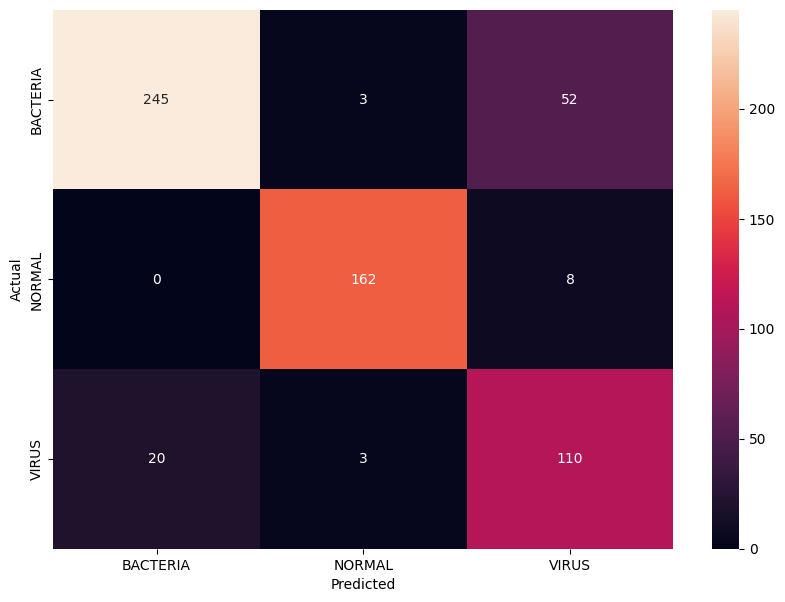

In [9]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

if 'dataloaders' in locals():
    evaluate_model(model_ft, dataloaders['val'])

## Explainability (Grad-CAM)

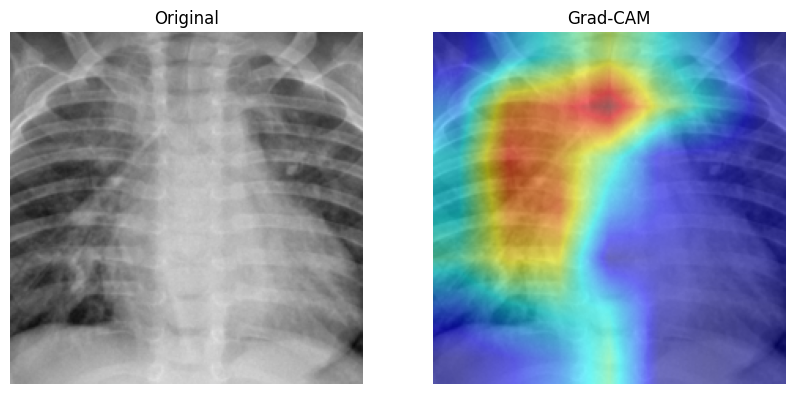

In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(model, image_tensor, target_class=None):
    """
    Visualize Grad-CAM for a specific image.
    target_class: int, class index to visualize. If None, uses the highest predicted class.
    """
    model.eval()
    target_layers = [model.features.denseblock4.denselayer16.conv2]

    cam = GradCAM(model=model, target_layers=target_layers)

    # Prepare image
    input_tensor = image_tensor.unsqueeze(0).to(device)

    if target_class is None:
        targets = None # Predicted Class
    else:
        targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Denormalize image for visualization
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

# Visualize a few validation images
if 'dataloaders' in locals():
    inputs, labels = next(iter(dataloaders['val']))
    # Visualize the first image in the batch
    visualize_gradcam(model_ft, inputs[0])